Using test image: C:\Users\HP\Downloads\test\cats\cat_1.jpg
Test Image is classified as: Cat
Best matched training image: cat_1.jpg


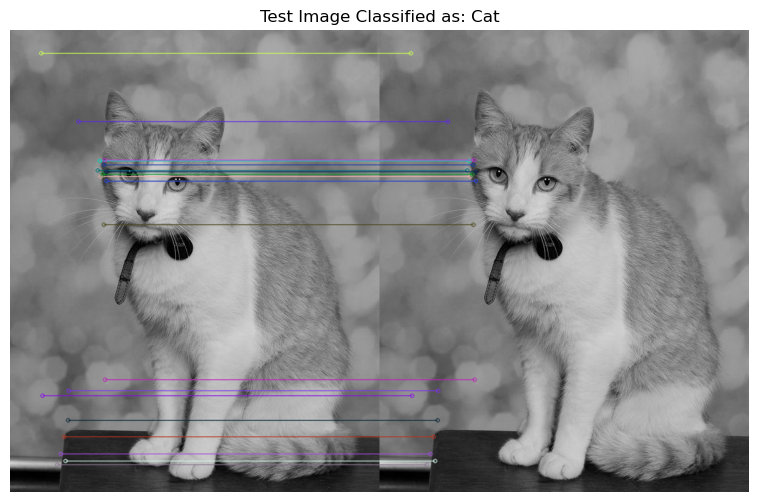

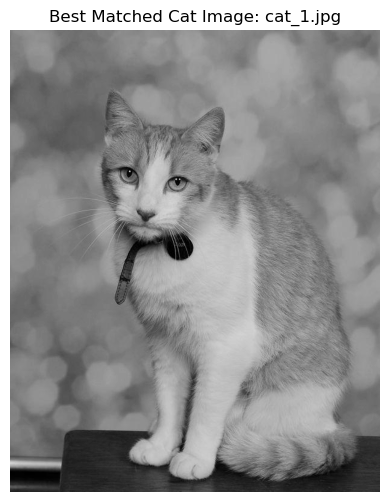

In [16]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Paths
cats_folder = r"C:\Users\HP\Downloads\test\cats"
dogs_folder = r"C:\Users\HP\Downloads\test\dogs"

# Automatically select the first cat image as the test image
cat_images = [f for f in os.listdir(cats_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]

if not cat_images:
    raise Exception("No cat images found in the 'cats' directory!")

test_image_path = os.path.join(cats_folder, cat_images[0])  # Pick first cat image
print(f"Using test image: {test_image_path}")

# Function to load images from a folder
def load_images_from_folder(folder):
    images = []
    filenames = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png', '.jpeg'))]

    for file in filenames:
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append((file, img))  # Store filename and image

    return images

# Load training images
cat_images = load_images_from_folder(cats_folder)
dog_images = load_images_from_folder(dogs_folder)

if not cat_images or not dog_images:
    raise Exception("No images found in one of the folders!")

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Extract SIFT features for cats
cat_descriptors = []
cat_keypoints = []
cat_filenames = []
for filename, img in cat_images:
    kp, des = sift.detectAndCompute(img, None)
    if des is not None:
        cat_descriptors.append(des)
        cat_keypoints.append(kp)
        cat_filenames.append(filename)

# Extract SIFT features for dogs
dog_descriptors = []
dog_keypoints = []
dog_filenames = []
for filename, img in dog_images:
    kp, des = sift.detectAndCompute(img, None)
    if des is not None:
        dog_descriptors.append(des)
        dog_keypoints.append(kp)
        dog_filenames.append(filename)

# Flatten descriptors
cat_descriptors = np.vstack(cat_descriptors)
dog_descriptors = np.vstack(dog_descriptors)

# Load test image
test_img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
if test_img is None:
    raise Exception("Test image not found!")

# Extract SIFT features from test image
kp_test, des_test = sift.detectAndCompute(test_img, None)

# Use FLANN-based matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Match test image against cat and dog descriptors
matches_cats = flann.knnMatch(des_test, cat_descriptors, k=2)
matches_dogs = flann.knnMatch(des_test, dog_descriptors, k=2)

# Apply Lowe’s ratio test
def filter_good_matches(matches):
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    return good_matches

good_matches_cats = filter_good_matches(matches_cats)
good_matches_dogs = filter_good_matches(matches_dogs)

# Determine classification
if len(good_matches_cats) > len(good_matches_dogs):
    result = "Cat"
    matched_folder = cats_folder
    matched_images = cat_images
    matched_keypoints = cat_keypoints
    matched_filenames = cat_filenames
else:
    result = "Dog"
    matched_folder = dogs_folder
    matched_images = dog_images
    matched_keypoints = dog_keypoints
    matched_filenames = dog_filenames

# Find best-matching image
best_match_img = None
best_match_kp = None
best_match_filename = None
max_matches = 0

for idx, (_, img) in enumerate(matched_images):
    kp_train, des_train = sift.detectAndCompute(img, None)
    matches = flann.knnMatch(des_test, des_train, k=2)
    good_matches = filter_good_matches(matches)

    if len(good_matches) > max_matches:
        max_matches = len(good_matches)
        best_match_img = img
        best_match_kp = kp_train
        best_match_filename = matched_filenames[idx]

# Display classification result
print(f"Test Image is classified as: {result}")
if best_match_filename:
    print(f"Best matched training image: {best_match_filename}")

# Draw matches with the best-matching image (LIMITED TO TOP 20)
if best_match_img is not None:
    # Sort matches by distance (lower distance = better match)
    best_matches = sorted(good_matches_cats if result == "Cat" else good_matches_dogs, key=lambda x: x.distance)

    # Keep only the top 20 matches
    best_matches = best_matches[:20]

    # Draw matches with limited keypoints
    result_img = cv2.drawMatches(test_img, kp_test, best_match_img, best_match_kp, 
                                 best_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    # Show the result
    plt.figure(figsize=(10, 6))
    plt.imshow(result_img, cmap='gray')
    plt.title(f"Test Image Classified as: {result}")
    plt.axis("off")
    plt.show()

    # Show the matched training image
    plt.figure(figsize=(6, 6))
    plt.imshow(best_match_img, cmap='gray')
    plt.title(f"Best Matched {result} Image: {best_match_filename}")
    plt.axis("off")
    plt.show()
